In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import xgboost
from xgboost import XGBClassifier
from xgboost import to_graphviz

In [2]:
def classification_metrics(y_actual, y_pred):
    acc = round(accuracy_score(y_actual, y_pred)*100, 2)
    precision = round(precision_score(y_actual, y_pred)*100, 2)
    recall = round(recall_score(y_actual, y_pred)*100, 2)
    f1 = round(f1_score(y_actual, y_pred)*100, 2)
    return {"Accuracy":acc, "Precision":precision, "Recall":recall, "F1":f1}

In [3]:
# Loading dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    'age','workclass','fnlwgt','education','education_num','marital_status',
    'occupation','relationship','race','sex','capital_gain','capital_loss',
    'hours_per_week','native_country','income'
]

In [4]:
df = pd.read_csv(url, header=None, names=columns, na_values=" ?")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
df.income.value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [6]:
df.shape

(32561, 15)

In [7]:
df.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [8]:
df = df.dropna()
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [9]:
df.shape

(30162, 15)

In [11]:
# encoding categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [12]:
X = df.drop("income", axis=1)
y = df["income"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
# decision tree
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
classification_metrics(y_test, y_pred_dt)

{'Accuracy': 83.67, 'Precision': 78.38, 'Recall': 47.54, 'F1': 59.18}

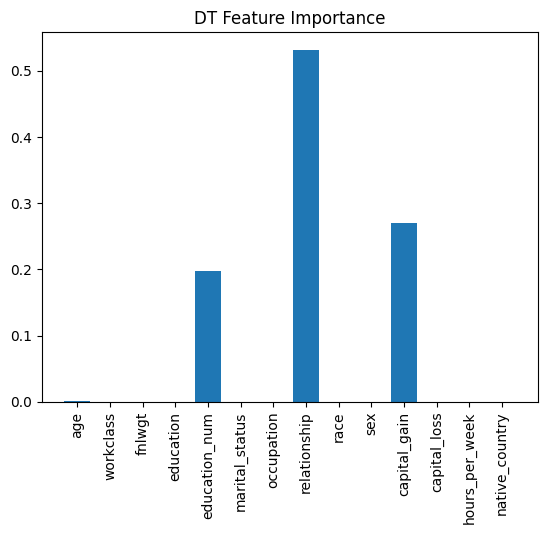

In [15]:
plt.figure()
plt.bar(X.columns, dt.feature_importances_)
plt.xticks(rotation=90)
plt.title("DT Feature Importance")
plt.show()

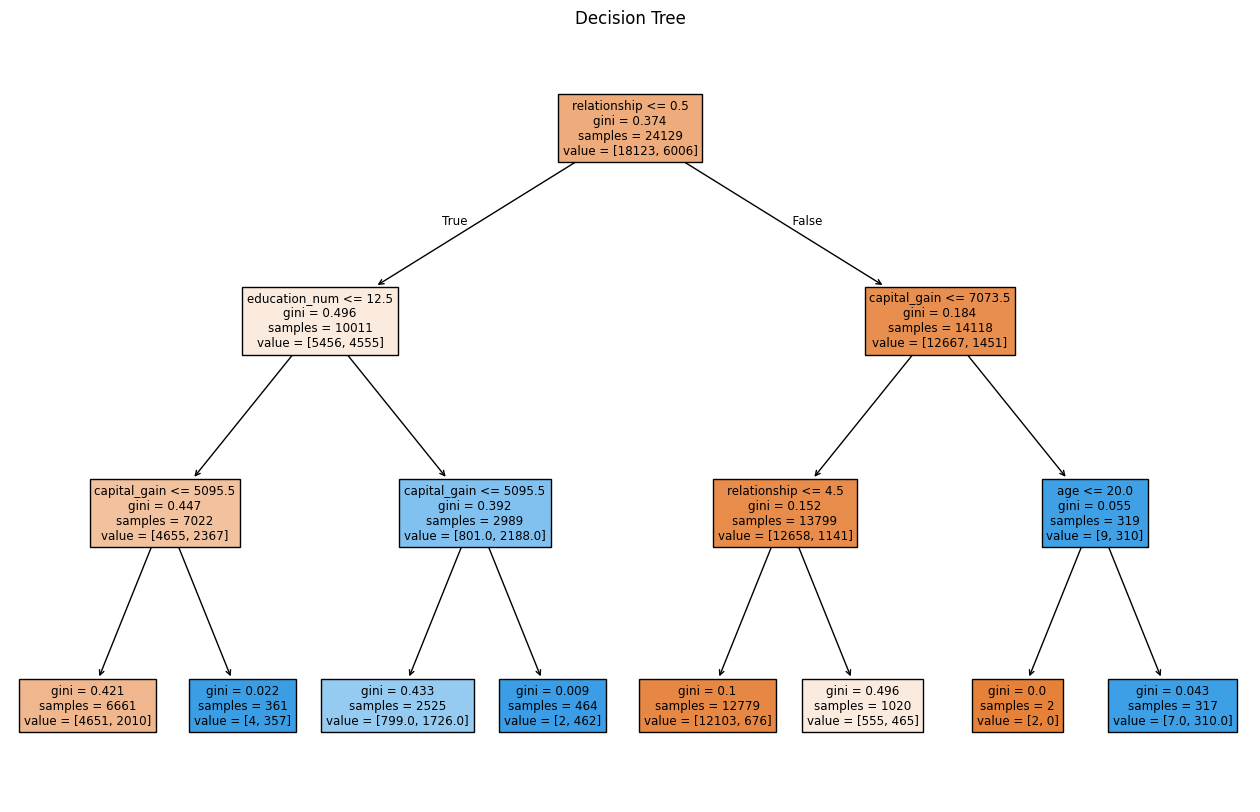

In [16]:
plt.figure(figsize=(16,10))
plot_tree(dt, feature_names=X.columns, filled=True)
plt.title("Decision Tree")
plt.show()

In [17]:
# random forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
classification_metrics(y_test, y_pred_rf)

{'Accuracy': 85.28, 'Precision': 79.75, 'Recall': 54.79, 'F1': 64.96}

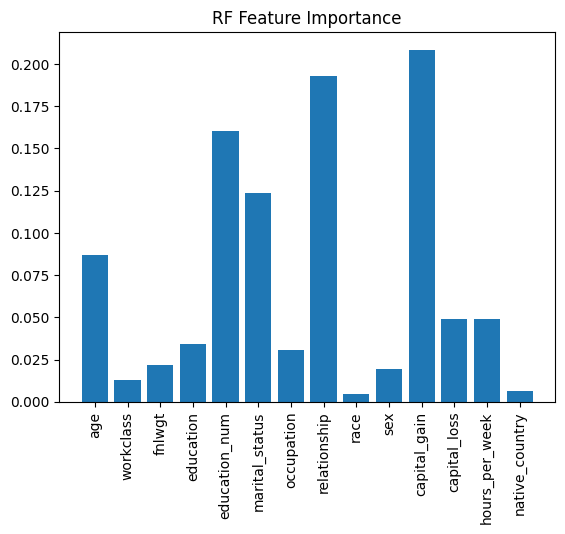

In [18]:
plt.figure()
plt.bar(X.columns, rf.feature_importances_)
plt.xticks(rotation=90)
plt.title("RF Feature Importance")
plt.show()

In [19]:
# gradient boosting
gb = GradientBoostingClassifier(n_estimators=100)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
classification_metrics(y_test, y_pred_gb)

{'Accuracy': 85.89, 'Precision': 78.38, 'Recall': 59.85, 'F1': 67.87}

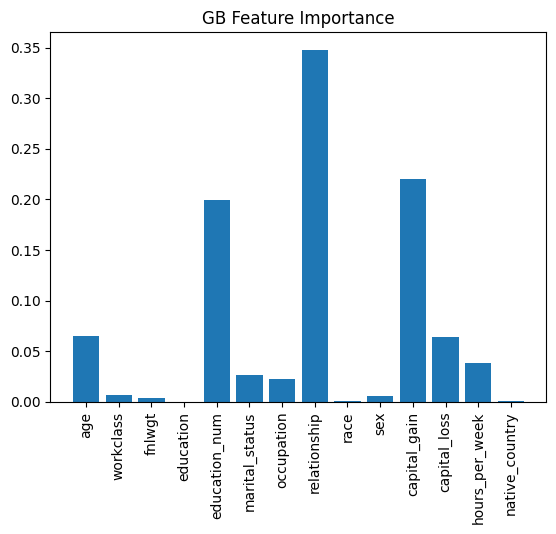

In [20]:
plt.figure()
plt.bar(X.columns, gb.feature_importances_)
plt.xticks(rotation=90)
plt.title("GB Feature Importance")
plt.show()

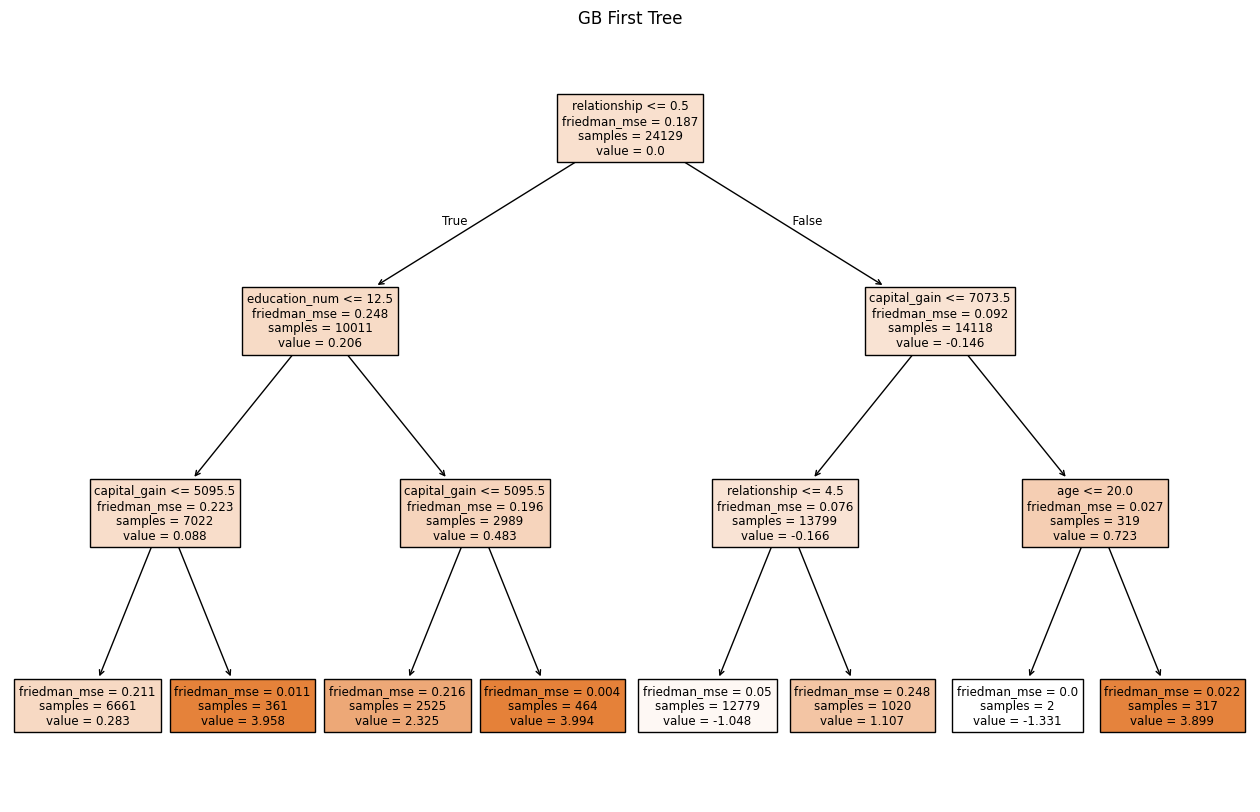

In [21]:
# visualize one tree
plt.figure(figsize=(16,10))
plot_tree(gb.estimators_[0,0], feature_names=X.columns, filled=True)
plt.title("GB First Tree")
plt.show()

In [22]:
# XGBoost
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, eval_metric="logloss")
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
classification_metrics(y_test, y_pred_xgb)

{'Accuracy': 86.44, 'Precision': 77.94, 'Recall': 63.52, 'F1': 69.99}

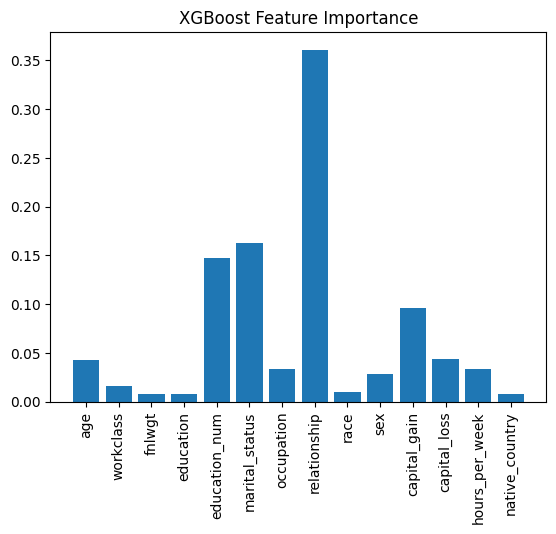

In [23]:
# Feature importance
plt.figure()
plt.bar(X.columns, xgb.feature_importances_)
plt.xticks(rotation=90)
plt.title("XGBoost Feature Importance")
plt.show()

<Figure size 4000x3000 with 0 Axes>

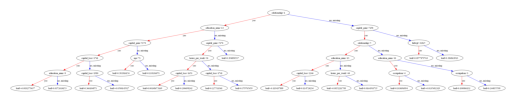

In [24]:
plt.figure(figsize=(40, 30))
xgboost.plot_tree(xgb, tree_idx=0) # plots the first tree at index 0
plt.show()

In [25]:
# saving to a file
dot = to_graphviz(xgb, tree_idx=0)
dot.render("xgboost_tree")

'xgboost_tree.pdf'

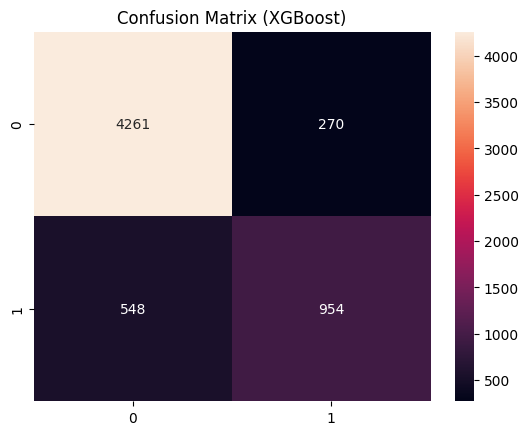

In [26]:
# best-performing model
best_pred = y_pred_xgb
cm = confusion_matrix(y_test, best_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix (XGBoost)")
plt.show()

**Exercise**
1. Use cross-validation on the above problem. How does this affect performance if at all?


In [27]:
# Part 1 Using cross-validation  on XG Boost

from sklearn.model_selection import cross_val_score

# Train with cross-validation , k= 5
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric="logloss"
)
cv_scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)
print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

# Train normally with cross validation
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
classification_metrics(y_test, y_pred_xgb)

Cross-validation scores: [0.87484459 0.86904269 0.86614173 0.86634894 0.87046632]
Mean CV accuracy: 0.8693688547998857


{'Accuracy': 86.44, 'Precision': 77.94, 'Recall': 63.52, 'F1': 69.99}

The performance of the XGBoost model did not change significantly after applying cross-validation. The cross-validation accuracy (0.8694) was very close to the accuracy obtained using a single train-test split (0.8644). This indicates that the model is stable and generalizes well to unseen data. Cross-validation mainly provided a more reliable estimate of performance rather than improving it.

2. Select two models and perform hyperparameter optimization to select the best hyperparameters. How does this affect the performance of the models?

In [32]:
# Part 2
# Hyperparamter optimization for Random forests

from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2,5]
}

rf = RandomForestClassifier()
grid_rf = GridSearchCV(rf, params, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
0.8586764009284767


In [33]:
#Hyperparameter optimization for Gradient Boosting

gb = GradientBoostingClassifier()

param_grid_gb = {
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'max_depth': [3, 5]
}

grid_gb = GridSearchCV(
    gb,
    param_grid_gb,
    cv=5,
    scoring='accuracy'
)

grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_

print(grid_gb.best_params_)
print(grid_gb.best_score_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
0.8702392438196386


The performance improvement was minimal, that is to say Random forests without optimizing hyperparameter(85.28) and with hyperparamter optimization (0.8587) and for Gradient boosting before is (85.89) and after (0.8702).
Indicating that the default parameters were already close to optimal for this dataset.


3. Choose a simple regression problem of your choice and use the above algorithms for prediction. Provide a comparison of their performance and their feature importance.

In [49]:
#Part 3
# Regression problem for predicting house prices

# using house price prediction dataset
df = pd.read_csv(r"C:\Users\user\Desktop\Data sets\House Price Prediction Dataset.csv")

# Encoding features
# Garage presence or absence
df['Garage'] = df['Garage'].map({'Yes': 1, 'No': 0})

# Condition of House
condition_map = {
    'Poor': 0,
    'Fair': 1,
    'Good': 2,
    'Excellent': 3
}

df['Condition'] = df['Condition'].map(condition_map)

# Location of house
df = pd.get_dummies(df, columns=['Location'], drop_first=True)

# Feature matrix and target vector
features = df.drop(columns = ["Price","Id"])
target = df["Price"]
X = features
y = target

# Train Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
#Train the 4 models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

models = {
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)  # R² score
    results[name] = score
    print(f"{name}: {score}")

Decision Tree: -1.08432750690572
Random Forest: -0.10437568356576898
Gradient Boosting: -0.03534905343592354
XGBoost: -0.32231903076171875


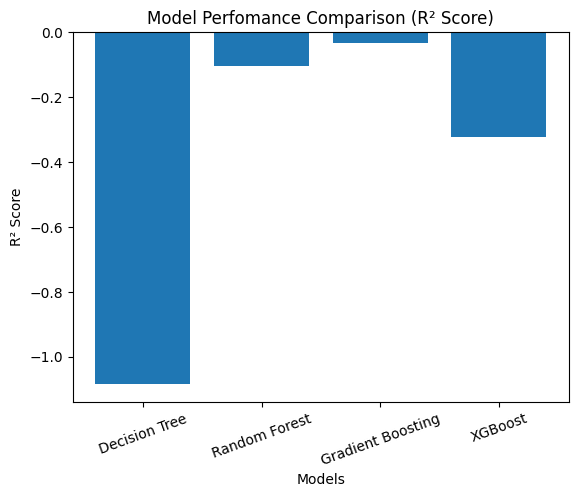

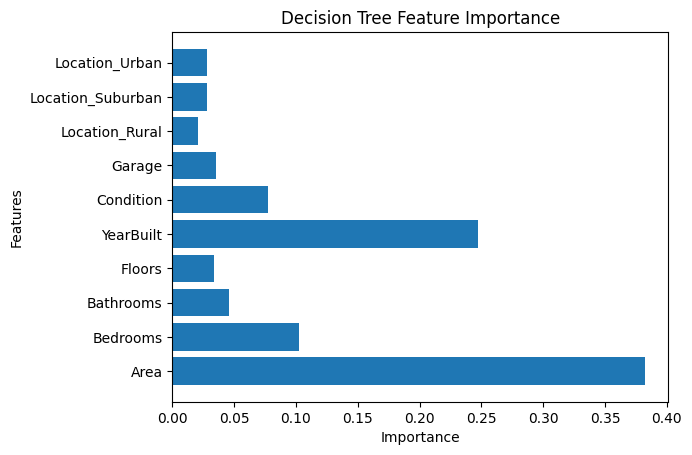

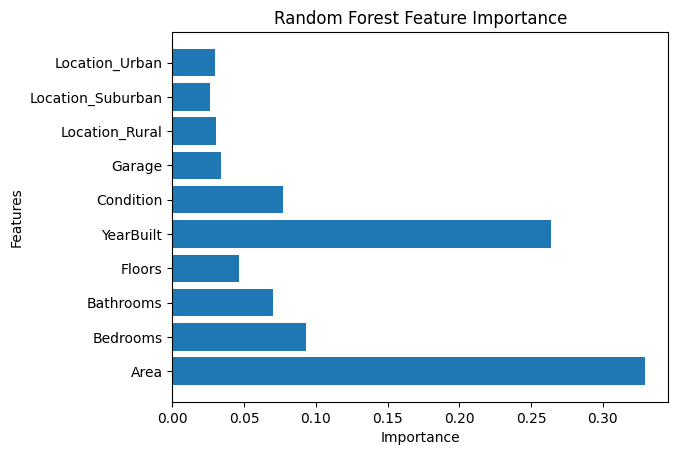

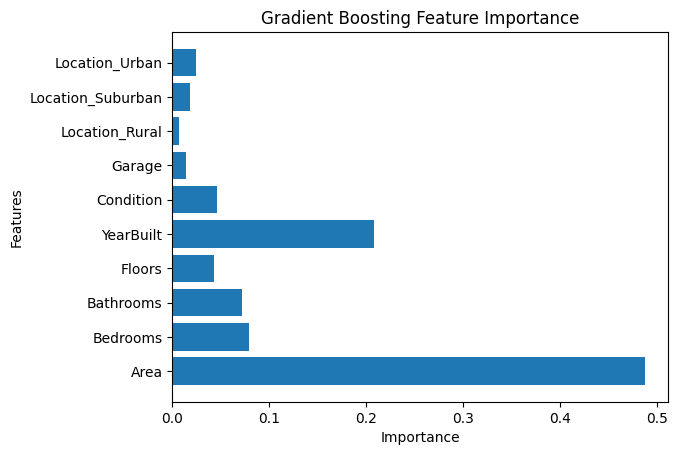

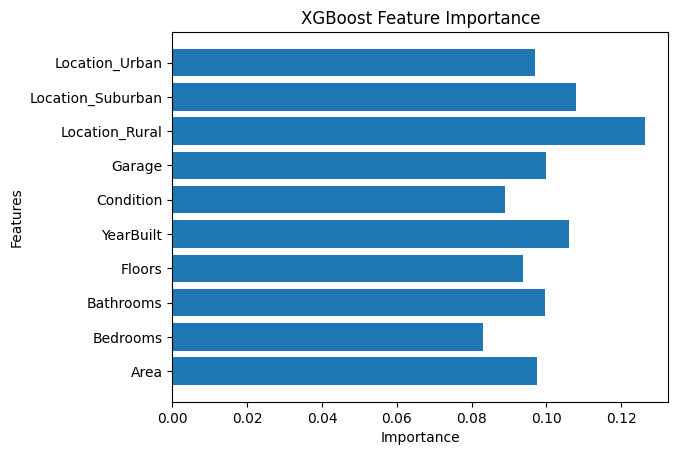

In [51]:
# Visualize Performance

names = list(results.keys())
scores = list(results.values())

plt.figure()
plt.bar(names, scores)
plt.title("Model Perfomance Comparison (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.show()

# Extract Feature Importance

feature_importance = {}

for name, model in models.items():
    if hasattr(model, "feature_importances_"):
        feature_importance[name] = model.feature_importances_

# Virtualize feature Importance
feature_names = X_train.columns  

for name, importance in feature_importance.items():
    plt.figure()
    plt.barh(feature_names, importance)
    plt.title(f"{name} Feature Importance")
    plt.xlabel("Importance")
    plt.ylabel("Features")
    plt.show()